In [1]:
# Environment Setup & Installs
!pip install wandb grad-cam lime scikit-image

In [2]:
# Imports & Device Setup

# Core Python
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# TorchVision
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_recall_fscore_support

# Explainability
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Weights & Biases
import wandb

# Environment
warnings.filterwarnings("ignore")

# Reproducibility
def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

# Device setup (prefer CUDA in Colab)
if torch.cuda.is_available():
    device = "cuda"
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    device = "cpu"
    print("Using CPU")

print(f"PyTorch Version: {torch.__version__}")
print(f"Random seed set to: {SEED}")

In [3]:
## Data Paths & CSV Loading

# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # Data paths
# DR_DATA_SOURCE = "/content/drive/MyDrive/RetinXplain/dr-data"
# DR_DATA_LOCAL = "/content/dr-data-local"

# # Copy data if not present
# if not os.path.exists(DR_DATA_LOCAL):
#     print(f"Copying data from {DR_DATA_SOURCE} to {DR_DATA_LOCAL}...")
#     !cp -r "{DR_DATA_SOURCE}" "{DR_DATA_LOCAL}"
#     print("Data copy complete.")
# else:
#     print(f"Local data directory {DR_DATA_LOCAL} already exists. Skipping copy.")

# Set root paths
DATA_ROOT = "../data" 
APTOS_ROOT = os.path.join(DATA_ROOT, "aptos")

# CSV paths
train_csv_path = os.path.join(APTOS_ROOT, "train.csv")
val_csv_path = os.path.join(APTOS_ROOT, "valid.csv")
test_csv_path = os.path.join(APTOS_ROOT, "test.csv")

# Image directories
train_images = os.path.join(APTOS_ROOT, "train_images")
valid_images = os.path.join(APTOS_ROOT, "val_images")
test_images = os.path.join(APTOS_ROOT, "test_images")

# Load CSVs
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# Helper: Filter DataFrame by image existence
def _filter_dataframe_by_image_existence(df, image_dir):
    """Filter DataFrame to only include rows where images actually exist."""
    existing_images = []
    for img_id in df['id_code']:
        png_path = os.path.join(image_dir, f"{img_id}.png")
        jpg_path = os.path.join(image_dir, f"{img_id}.jpg")
        if os.path.exists(png_path) or os.path.exists(jpg_path):
            existing_images.append(img_id)
    return df[df['id_code'].isin(existing_images)]

# Filter to ensure all images exist
train_df = _filter_dataframe_by_image_existence(train_df, train_images)
val_df = _filter_dataframe_by_image_existence(val_df, valid_images)
test_df = _filter_dataframe_by_image_existence(test_df, test_images)

print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

In [4]:
## Configuration

# Model hyperparameters
NUM_CLASSES = 5
TOTAL_EPOCHS = 60        # Increased from 30 for better convergence
UNFREEZE_EPOCH = 10      # Delayed from 3 to let head learn first

# Learning rates - LOWERED to prevent loss plateau
HEAD_LR = 5e-5           # Reduced from 3e-4 (6x lower)
BACKBONE_LR = 1e-5       # Reduced from 1e-4 (10x lower)
WEIGHT_DECAY = 1e-4

# Image preprocessing - INCREASED for better feature capture
IMG_RESIZE = 456         # Increased from 380
CROP_SIZE = 456          # Increased from 380
BATCH_SIZE = 32

# Loss function
LABEL_SMOOTHING = 0.1    # Increased from 0.05 for better regularization

# Early stopping
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for 10 epochs

# Model paths
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b4_best_cleaned.pt")

# Explainability
GRADCAM_LAYER_INDEX = -1
LIME_NUM_FEATURES = 8
LIME_NUM_SAMPLES = 200
N_EXPLAINABILITY_EXAMPLES = 6

# W&B configuration
WANDB_PROJECT = "retinexplain-dr"
WANDB_RUN_NAME = "efficientnet-b4-aptos"
WANDB_TAGS = ["efficientnet-b4", "aptos", "diabetic-retinopathy", "5-class"]

print("Configuration loaded:")
print(f"  Model: EfficientNet-B4")
print(f"  Epochs: {TOTAL_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {CROP_SIZE}x{CROP_SIZE}")
print(f"  Head LR: {HEAD_LR}, Backbone LR: {BACKBONE_LR}")
print(f"  Unfreeze epoch: {UNFREEZE_EPOCH}")

In [5]:
## Dataset Summary & Class Distribution

# Class names
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

# Dataset summary
def print_dataset_summary(df, split_name):
    """Print dataset size and class distribution."""
    print(f"\n{split_name}: {len(df):5d} samples")
    counts = df["diagnosis"].value_counts().sort_index()
    for k, v in counts.items():
        print(f"  {k} ({class_names[k]:20s}): {v:5d} ({v/len(df)*100:5.2f}%)")

print("=" * 60)
print("Dataset Summary")
print("=" * 60)
print_dataset_summary(train_df, "Train")
print_dataset_summary(val_df, "Validation")
print_dataset_summary(test_df, "Test")

In [6]:
## Transforms & Preprocessing

# Custom preprocessing classes
class SmartFundusCrop:
    """Better fundus crop removing black borders + isolating retina circle."""
    def __call__(self, img):
        np_img = np.array(img)
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
        
        # Threshold non-black area
        _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)
        
        if coords is None:
            return img  # fallback to original
        
        x, y, w, h = cv2.boundingRect(coords)
        cropped = np_img[y:y+h, x:x+w]
        
        # Square crop around center
        h2, w2 = cropped.shape[:2]
        side = int(min(w2, h2) * 0.95)
        cx, cy = w2 // 2, h2 // 2
        x0, y0 = cx - side//2, cy - side//2
        square = cropped[y0:y0+side, x0:x0+side]
        
        return Image.fromarray(square)


# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Data transforms
data_transforms = {
    "training": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.RandomResizedCrop(CROP_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),  # More aggressive
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Add vertical flip
        transforms.RandomRotation(15),  # Increased from 10
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),  # Stronger
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Add translation/scale
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # Add random erasing for regularization
    ]),
    
    "validation": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    
    "testing": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}


def denorm(img_tensor):
    """Undo ImageNet normalization for visualization."""
    if img_tensor.ndim == 3:
        # single image: [C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    elif img_tensor.ndim == 4:
        # batch: [B, C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(1, 3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unsupported tensor shape for denorm: {img_tensor.shape}")
    return img_tensor * std + mean

In [7]:
## Dataset & Dataloaders

class FundusDataset(Dataset):
    """Diabetic Retinopathy Fundus Image Dataset (for classification)."""
    
    def __init__(self, df, root_dir, transform=None):
        """
        Args:
            df: DataFrame with 'id_code' and 'diagnosis' columns
            root_dir: Directory with all the images
            transform: Optional transform to apply on an image
        """
        self.labels_frame = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.labels_frame)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img_id = str(self.labels_frame.iloc[idx, 0])
        label = int(self.labels_frame.iloc[idx, 1])
        
        # Try PNG first, then JPG
        img_path = os.path.join(self.root_dir, f"{img_id}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"No image found for {img_id} in {self.root_dir}")
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        return image, label, img_id


# Create datasets
train_ds = FundusDataset(df=train_df, root_dir=train_images, transform=data_transforms["training"])
val_ds = FundusDataset(df=val_df, root_dir=valid_images, transform=data_transforms["validation"])
test_ds = FundusDataset(df=test_df, root_dir=test_images, transform=data_transforms["testing"])

# WeightedRandomSampler for training - Improved class weighting
class_counts = train_df["diagnosis"].value_counts().sort_index()
total_samples = len(train_df)

# Use inverse frequency weighting (better for imbalanced classes)
class_weights = total_samples / (NUM_CLASSES * class_counts)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # Normalize

class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32, device=device)

# Print class weights for verification
print("\nClass weights for loss function:")
for i, w in enumerate(class_weights):
    print(f"  Class {i} ({class_names[i]:20s}): {w:.4f} (count: {class_counts[i]})")

sample_weights = torch.DoubleTensor(train_df["diagnosis"].map(class_weights.to_dict()).values)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# Create dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    pin_memory=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}

print(f"Train dataloader: {len(train_loader)} batches")
print(f"Val dataloader: {len(val_loader)} batches")
print(f"Test dataloader: {len(test_loader)} batches")

In [8]:
## Sanity Check Visualization
def show_batch(images, labels, n=24, ncols=6):
    """
    Display a batch of images with their labels.
    
    Args:
        images: Tensor of images [B, C, H, W] (can be on any device)
        labels: Tensor of labels [B] (can be on any device)
        n: Number of images to display (default: 24)
        ncols: Number of columns in the grid (default: 6)
    """
    # Ensure images and labels are on CPU for visualization
    if isinstance(images, torch.Tensor):
        images = images.cpu()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu()
    
    n = min(n, len(images))
    nrows = int(np.ceil(n / ncols))
    
    # Use square figsize that scales with grid dimensions to preserve aspect ratio
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    
    # Convert axes to a flat list for easier indexing
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    elif nrows == 1:
        axes_list = list(axes) if hasattr(axes, '__iter__') else [axes]
    elif ncols == 1:
        axes_list = list(axes.flatten()) if hasattr(axes, 'flatten') else [axes]
    else:
        axes_list = list(axes.flatten())
    
    for i in range(n):
        ax = axes_list[i]
        
        # Denormalize and convert to numpy
        img = denorm(images[i])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_aspect("equal")  # Preserve 1:1 aspect ratio so fundus images appear round
        ax.axis('off')
        
        label_text = CLASS_NAMES[int(labels[i])]
        ax.text(
            5, 15, label_text,
            color='white', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )
    
    # Hide unused subplots
    for i in range(n, len(axes_list)):
        axes_list[i].axis('off')
    
    plt.tight_layout()
    plt.show()


print("✓ Data visualization utilities defined!")
print("  - denorm(img_tensor): Denormalize ImageNet-normalized images")
print("  - show_batch(images, labels, n, ncols): Display a batch of images with labels")

#Test visualization (uncomment to run after get_dataloaders is defined)
#train_loader, val_loader, _, _ = get_dataloaders()

# Visualize a batch from training set
print("\nTraining batch sample:")
inputs, labels, img_ids = next(iter(train_loader))
show_batch(inputs, labels, n=12, ncols=6)

# Visualize a batch from validation set  
print("\nValidation batch sample:")
val_inputs, val_labels, val_img_ids = next(iter(val_loader))
show_batch(val_inputs, val_labels, n=12, ncols=6)

In [9]:
# Environment Setup & Installs
!pip install wandb grad-cam lime scikit-image

In [10]:
# Imports & Device Setup

# Core Python
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# TorchVision
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_recall_fscore_support

# Explainability
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Weights & Biases
import wandb

# Environment
warnings.filterwarnings("ignore")

# Reproducibility
def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

# Device setup (prefer CUDA in Colab)
if torch.cuda.is_available():
    device = "cuda"
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    device = "cpu"
    print("Using CPU")

print(f"PyTorch Version: {torch.__version__}")
print(f"Random seed set to: {SEED}")

In [11]:
## Data Paths & CSV Loading

# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # Data paths
# DR_DATA_SOURCE = "/content/drive/MyDrive/RetinXplain/dr-data"
# DR_DATA_LOCAL = "/content/dr-data-local"

# # Copy data if not present
# if not os.path.exists(DR_DATA_LOCAL):
#     print(f"Copying data from {DR_DATA_SOURCE} to {DR_DATA_LOCAL}...")
#     !cp -r "{DR_DATA_SOURCE}" "{DR_DATA_LOCAL}"
#     print("Data copy complete.")
# else:
#     print(f"Local data directory {DR_DATA_LOCAL} already exists. Skipping copy.")

# Set root paths
DATA_ROOT = "../data" 
APTOS_ROOT = os.path.join(DATA_ROOT, "aptos")

# CSV paths
train_csv_path = os.path.join(APTOS_ROOT, "train.csv")
val_csv_path = os.path.join(APTOS_ROOT, "valid.csv")
test_csv_path = os.path.join(APTOS_ROOT, "test.csv")

# Image directories
train_images = os.path.join(APTOS_ROOT, "train_images")
valid_images = os.path.join(APTOS_ROOT, "val_images")
test_images = os.path.join(APTOS_ROOT, "test_images")

# Load CSVs
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# Helper: Filter DataFrame by image existence
def _filter_dataframe_by_image_existence(df, image_dir):
    """Filter DataFrame to only include rows where images actually exist."""
    existing_images = []
    for img_id in df['id_code']:
        png_path = os.path.join(image_dir, f"{img_id}.png")
        jpg_path = os.path.join(image_dir, f"{img_id}.jpg")
        if os.path.exists(png_path) or os.path.exists(jpg_path):
            existing_images.append(img_id)
    return df[df['id_code'].isin(existing_images)]

# Filter to ensure all images exist
train_df = _filter_dataframe_by_image_existence(train_df, train_images)
val_df = _filter_dataframe_by_image_existence(val_df, valid_images)
test_df = _filter_dataframe_by_image_existence(test_df, test_images)

print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

In [12]:
## Configuration

# Model hyperparameters
NUM_CLASSES = 5
TOTAL_EPOCHS = 60        # Increased from 30 for better convergence
UNFREEZE_EPOCH = 10      # Delayed from 3 to let head learn first

# Learning rates - LOWERED to prevent loss plateau
HEAD_LR = 5e-5           # Reduced from 3e-4 (6x lower)
BACKBONE_LR = 1e-5       # Reduced from 1e-4 (10x lower)
WEIGHT_DECAY = 1e-4

# Image preprocessing - INCREASED for better feature capture
IMG_RESIZE = 456         # Increased from 380
CROP_SIZE = 456          # Increased from 380
BATCH_SIZE = 32

# Loss function
LABEL_SMOOTHING = 0.1    # Increased from 0.05 for better regularization

# Early stopping
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for 10 epochs

# Model paths
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b4_best_cleaned.pt")

# Explainability
GRADCAM_LAYER_INDEX = -1
LIME_NUM_FEATURES = 8
LIME_NUM_SAMPLES = 200
N_EXPLAINABILITY_EXAMPLES = 6

# W&B configuration
WANDB_PROJECT = "retinexplain-dr"
WANDB_RUN_NAME = "efficientnet-b4-aptos"
WANDB_TAGS = ["efficientnet-b4", "aptos", "diabetic-retinopathy", "5-class"]

print("Configuration loaded:")
print(f"  Model: EfficientNet-B4")
print(f"  Epochs: {TOTAL_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {CROP_SIZE}x{CROP_SIZE}")
print(f"  Head LR: {HEAD_LR}, Backbone LR: {BACKBONE_LR}")
print(f"  Unfreeze epoch: {UNFREEZE_EPOCH}")

In [13]:
## Dataset Summary & Class Distribution

# Class names
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

# Dataset summary
def print_dataset_summary(df, split_name):
    """Print dataset size and class distribution."""
    print(f"\n{split_name}: {len(df):5d} samples")
    counts = df["diagnosis"].value_counts().sort_index()
    for k, v in counts.items():
        print(f"  {k} ({class_names[k]:20s}): {v:5d} ({v/len(df)*100:5.2f}%)")

print("=" * 60)
print("Dataset Summary")
print("=" * 60)
print_dataset_summary(train_df, "Train")
print_dataset_summary(val_df, "Validation")
print_dataset_summary(test_df, "Test")

In [14]:
## Transforms & Preprocessing

# Custom preprocessing classes
class SmartFundusCrop:
    """Better fundus crop removing black borders + isolating retina circle."""
    def __call__(self, img):
        np_img = np.array(img)
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
        
        # Threshold non-black area
        _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)
        
        if coords is None:
            return img  # fallback to original
        
        x, y, w, h = cv2.boundingRect(coords)
        cropped = np_img[y:y+h, x:x+w]
        
        # Square crop around center
        h2, w2 = cropped.shape[:2]
        side = int(min(w2, h2) * 0.95)
        cx, cy = w2 // 2, h2 // 2
        x0, y0 = cx - side//2, cy - side//2
        square = cropped[y0:y0+side, x0:x0+side]
        
        return Image.fromarray(square)


# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Data transforms
data_transforms = {
    "training": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.RandomResizedCrop(CROP_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),  # More aggressive
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Add vertical flip
        transforms.RandomRotation(15),  # Increased from 10
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),  # Stronger
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Add translation/scale
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # Add random erasing for regularization
    ]),
    
    "validation": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    
    "testing": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}


def denorm(img_tensor):
    """Undo ImageNet normalization for visualization."""
    if img_tensor.ndim == 3:
        # single image: [C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    elif img_tensor.ndim == 4:
        # batch: [B, C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(1, 3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unsupported tensor shape for denorm: {img_tensor.shape}")
    return img_tensor * std + mean

In [15]:
## Dataset & Dataloaders

class FundusDataset(Dataset):
    """Diabetic Retinopathy Fundus Image Dataset (for classification)."""
    
    def __init__(self, df, root_dir, transform=None):
        """
        Args:
            df: DataFrame with 'id_code' and 'diagnosis' columns
            root_dir: Directory with all the images
            transform: Optional transform to apply on an image
        """
        self.labels_frame = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.labels_frame)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img_id = str(self.labels_frame.iloc[idx, 0])
        label = int(self.labels_frame.iloc[idx, 1])
        
        # Try PNG first, then JPG
        img_path = os.path.join(self.root_dir, f"{img_id}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"No image found for {img_id} in {self.root_dir}")
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        return image, label, img_id


# Create datasets
train_ds = FundusDataset(df=train_df, root_dir=train_images, transform=data_transforms["training"])
val_ds = FundusDataset(df=val_df, root_dir=valid_images, transform=data_transforms["validation"])
test_ds = FundusDataset(df=test_df, root_dir=test_images, transform=data_transforms["testing"])

# WeightedRandomSampler for training - Improved class weighting
class_counts = train_df["diagnosis"].value_counts().sort_index()
total_samples = len(train_df)

# Use inverse frequency weighting (better for imbalanced classes)
class_weights = total_samples / (NUM_CLASSES * class_counts)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # Normalize

class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32, device=device)

# Print class weights for verification
print("\nClass weights for loss function:")
for i, w in enumerate(class_weights):
    print(f"  Class {i} ({class_names[i]:20s}): {w:.4f} (count: {class_counts[i]})")

sample_weights = torch.DoubleTensor(train_df["diagnosis"].map(class_weights.to_dict()).values)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# Create dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    pin_memory=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}

print(f"Train dataloader: {len(train_loader)} batches")
print(f"Val dataloader: {len(val_loader)} batches")
print(f"Test dataloader: {len(test_loader)} batches")

In [16]:
## Sanity Check Visualization
def show_batch(images, labels, n=24, ncols=6):
    """
    Display a batch of images with their labels.
    
    Args:
        images: Tensor of images [B, C, H, W] (can be on any device)
        labels: Tensor of labels [B] (can be on any device)
        n: Number of images to display (default: 24)
        ncols: Number of columns in the grid (default: 6)
    """
    # Ensure images and labels are on CPU for visualization
    if isinstance(images, torch.Tensor):
        images = images.cpu()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu()
    
    n = min(n, len(images))
    nrows = int(np.ceil(n / ncols))
    
    # Use square figsize that scales with grid dimensions to preserve aspect ratio
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    
    # Convert axes to a flat list for easier indexing
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    elif nrows == 1:
        axes_list = list(axes) if hasattr(axes, '__iter__') else [axes]
    elif ncols == 1:
        axes_list = list(axes.flatten()) if hasattr(axes, 'flatten') else [axes]
    else:
        axes_list = list(axes.flatten())
    
    for i in range(n):
        ax = axes_list[i]
        
        # Denormalize and convert to numpy
        img = denorm(images[i])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_aspect("equal")  # Preserve 1:1 aspect ratio so fundus images appear round
        ax.axis('off')
        
        label_text = class_names[int(labels[i])]
        ax.text(
            5, 15, label_text,
            color='white', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )
    
    # Hide unused subplots
    for i in range(n, len(axes_list)):
        axes_list[i].axis('off')
    
    plt.tight_layout()
    plt.show()


print("✓ Data visualization utilities defined!")
print("  - denorm(img_tensor): Denormalize ImageNet-normalized images")
print("  - show_batch(images, labels, n, ncols): Display a batch of images with labels")

#Test visualization (uncomment to run after get_dataloaders is defined)
#train_loader, val_loader, _, _ = get_dataloaders()

# Visualize a batch from training set
print("\nTraining batch sample:")
inputs, labels, img_ids = next(iter(train_loader))
show_batch(inputs, labels, n=12, ncols=6)

# Visualize a batch from validation set  
print("\nValidation batch sample:")
val_inputs, val_labels, val_img_ids = next(iter(val_loader))
show_batch(val_inputs, val_labels, n=12, ncols=6)

In [17]:
## Model Definition: EfficientNet-B4

# Load EfficientNet-B4 with pretrained weights
weights = EfficientNet_B4_Weights.IMAGENET1K_V1
model = efficientnet_b4(weights=weights)

# Freeze all backbone features initially
for p in model.features.parameters():
    p.requires_grad = False

# Replace classifier for 5-class DR
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, NUM_CLASSES)

# Ensure classifier params are trainable
for p in model.classifier.parameters():
    p.requires_grad = True

# Move to device
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model loaded: EfficientNet-B4")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

In [18]:
## Weights & Biases Initialization

# W&B login (will prompt in Colab)
wandb.login()

# Comprehensive W&B configuration
wandb_config = {
    # Model
    "model": "efficientnet_b4",
    "num_classes": NUM_CLASSES,
    "pretrained": "ImageNet1K_V1",
    
    # Data
    "dataset": "APTOS",
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "img_size": CROP_SIZE,
    "batch_size": BATCH_SIZE,
    
    # Training
    "total_epochs": TOTAL_EPOCHS,
    "unfreeze_epoch": UNFREEZE_EPOCH,
    "head_lr": HEAD_LR,
    "backbone_lr": BACKBONE_LR,
    "weight_decay": WEIGHT_DECAY,
    
    # Loss
    "loss": "CrossEntropyLoss",
    "label_smoothing": LABEL_SMOOTHING,
    "class_weights": True,
    "sampling": "WeightedRandomSampler",
    
    # Augmentations
    "augmentations": [
        "SmartFundusCrop",
        f"Resize({IMG_RESIZE})",
        f"RandomResizedCrop({CROP_SIZE}, scale=(0.95, 1.0), ratio=(0.98, 1.02))",
        "RandomHorizontalFlip(p=0.5)",
        "RandomRotation(±10°)",
        "ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.02)",
        "ToTensor",
        "Normalize(ImageNet mean/std)"
    ],
    
    # Model architecture
    "total_params": total_params,
    "trainable_params": trainable_params,
    
    # Reproducibility
    "seed": SEED,
    
    # Explainability
    "gradcam_layer": GRADCAM_LAYER_INDEX,
    "lime_samples": LIME_NUM_SAMPLES,
}

# Initialize W&B run
wandb_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config=wandb_config,
    tags=WANDB_TAGS,
    notes="EfficientNet-B4 for 5-class Diabetic Retinopathy classification on APTOS dataset",
    save_code=True,
)

# Watch model with W&B (gradients and parameters)
wandb.watch(model, log="all", log_freq=100)

print("=" * 60)
print("Weights & Biases Initialized")
print("=" * 60)
print(f"Project: {wandb_run.project}")
print(f"Run: {wandb_run.name}")
print(f"Run ID: {wandb_run.id}")
print(f"URL: {wandb_run.url}")
print("=" * 60)

In [19]:
## Loss, Optimizer, Scheduler

# Loss function: CrossEntropyLoss with class weights and label smoothing
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)

# Optimizer: Start with only classifier parameters
optimizer = torch.optim.AdamW(
    [{"params": model.classifier.parameters(), "lr": HEAD_LR}],
    weight_decay=WEIGHT_DECAY,
)

# Scheduler: OneCycleLR (better for transfer learning)
# Note: OneCycleLR steps per batch, not per epoch
from torch.optim.lr_scheduler import OneCycleLR

scheduler = OneCycleLR(
    optimizer,
    max_lr=[HEAD_LR],  # Will update when backbone is unfrozen
    epochs=TOTAL_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,  # 10% of training for warmup
    anneal_strategy='cos',
    div_factor=25.0,  # Initial LR = max_lr / 25
    final_div_factor=10000.0  # Final LR = max_lr / 10000
)

print("Training setup complete:")
print(f"  Loss: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"  Optimizer: AdamW (head_lr={HEAD_LR}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler: OneCycleLR (max_lr={HEAD_LR}, steps_per_epoch={len(train_loader)})")
print(f"  Note: Scheduler steps per batch (not per epoch) for OneCycleLR")

In [20]:
# Helper functions
def get_current_lrs(optimizer):
    """Get current learning rates for all parameter groups."""
    return [group['lr'] for group in optimizer.param_groups]

def unfreeze_last_block(model):
    """Unfreeze the last EfficientNet-B4 blocks for fine-tuning."""
    for p in model.features[-3:].parameters():
        p.requires_grad = True

In [21]:
# Main training function
def train_model(model, criterion, optimizer, scheduler=None, num_epochs=30, patience=10):
    """Training loop with macro-F1 tracking and early stopping."""
    since = time.time()
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "lr_head": [],
        "lr_backbone": []
    }
    
    best_val_f1 = 0.0
    epochs_without_improvement = 0
    torch.save(model.state_dict(), BEST_MODEL_PATH)
    
    for epoch in range(num_epochs):
        epoch_lrs = get_current_lrs(optimizer)
        lr_msg = " | ".join([f"group {i}: {lr:.6f}" for i, lr in enumerate(epoch_lrs)])
        print(f"\nEpoch {epoch + 1}/{num_epochs}  |  LRs -> {lr_msg}")
        print("-" * 60)
        
        epoch_logs = {"epoch": epoch + 1}
        
        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []
            
            loop = tqdm(dataloaders[phase], desc=f"{phase:>5}", leave=False)
            for inputs, labels in loop:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # Step scheduler after each batch for OneCycleLR
                        # Note: OneCycleLR steps per batch, not per epoch
                        if scheduler is not None:
                            scheduler.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            epoch_macro_f1 = f1_score(all_labels, all_preds, average='macro')
            
            # Per-class F1 scores
            per_class_f1 = f1_score(all_labels, all_preds, average=None, labels=list(range(NUM_CLASSES)))
            
            # Per-class precision, recall, F1
            precision, recall, f1, support = precision_recall_fscore_support(
                all_labels, all_preds, labels=list(range(NUM_CLASSES)), zero_division=0
            )
            
            print(f"{phase:>5} | loss: {epoch_loss:.4f}  acc: {epoch_acc*100:5.2f}%  macro-F1: {epoch_macro_f1:.4f}")
            
            # Print per-class metrics for validation
            if phase == "val":
                print(f"  Per-class F1:")
                for i in range(NUM_CLASSES):
                    print(f"    Class {i} ({class_names[i]:20s}): {f1[i]:.3f} (P={precision[i]:.3f}, R={recall[i]:.3f}, Support={support[i]})")
            
            if phase == "train":
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc)
                history["train_macro_f1"].append(epoch_macro_f1)
                epoch_logs["train_loss"] = epoch_loss
                epoch_logs["train_acc"] = epoch_acc
                epoch_logs["train_macro_f1"] = epoch_macro_f1
                # Per-class F1 for training
                for i, f1_val in enumerate(per_class_f1):
                    epoch_logs[f"train_f1_class_{i}"] = f1_val
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc)
                history["val_macro_f1"].append(epoch_macro_f1)
                epoch_logs["val_loss"] = epoch_loss
                epoch_logs["val_acc"] = epoch_acc
                epoch_logs["val_macro_f1"] = epoch_macro_f1
                # Per-class F1 for validation
                for i, f1_val in enumerate(per_class_f1):
                    epoch_logs[f"val_f1_class_{i}"] = f1_val
                    epoch_logs[f"val_precision_class_{i}"] = precision[i]
                    epoch_logs[f"val_recall_class_{i}"] = recall[i]
                
                # Save best model based on validation macro-F1
                if epoch_macro_f1 > best_val_f1:
                    best_val_f1 = epoch_macro_f1
                    epochs_without_improvement = 0  # Reset counter
                    torch.save(model.state_dict(), BEST_MODEL_PATH)
                    print(f"  ✓ New best model saved (val macro-F1: {best_val_f1:.4f})")
                    # Log best model checkpoint to W&B summary
                    wandb.run.summary["best_val_macro_f1"] = best_val_f1
                    wandb.run.summary["best_epoch"] = epoch + 1
                else:
                    epochs_without_improvement += 1
                    print(f"  No improvement ({epochs_without_improvement}/{patience})")
        
        # Unfreeze last block at UNFREEZE_EPOCH
        if (epoch + 1) == UNFREEZE_EPOCH and len(optimizer.param_groups) == 1:
            print(">> Unfreezing last EfficientNet blocks and adding to optimizer")
            unfreeze_last_block(model)
            optimizer.add_param_group({
                "params": model.features[-3:].parameters(),
                "lr": BACKBONE_LR,
            })
            # Update OneCycleLR scheduler with new param group
            if scheduler is not None and hasattr(scheduler, "max_lr"):
                # OneCycleLR needs max_lr list updated when param groups change
                # Note: This is a limitation - OneCycleLR doesn't easily support dynamic param groups
                # For now, we'll continue with the existing scheduler
                print("  Note: OneCycleLR max_lr not updated (limitation of OneCycleLR)")
        
        # Record LRs
        epoch_lrs = get_current_lrs(optimizer)
        history["lr_head"].append(epoch_lrs[0])
        history["lr_backbone"].append(epoch_lrs[1] if len(epoch_lrs) > 1 else None)
        
        epoch_logs["lr_head"] = epoch_lrs[0]
        if len(epoch_lrs) > 1:
            epoch_logs["lr_backbone"] = epoch_lrs[1]
        epoch_logs["best_val_macro_f1"] = best_val_f1
        
        # Log to W&B
        wandb.log(epoch_logs)
        
        # Early stopping check
        if epochs_without_improvement >= patience:
            print(f"\n⚠️ Early stopping triggered after {epoch + 1} epochs")
            print(f"   No improvement for {patience} consecutive epochs")
            break
        
        dt = time.time() - since
        print(f"Time elapsed: {dt//60:.0f}m {dt%60:.0f}s  |  Best val macro-F1: {best_val_f1:.4f}")
    
    return model, history

In [22]:
## Training

# Run training with early stopping
model, history = train_model(
    model,
    criterion,
    optimizer,
    scheduler,
    num_epochs=TOTAL_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
)

print("\n" + "=" * 60)
print("Training Complete!")
print("=" * 60)

In [23]:
# Environment Setup & Installs
!pip install wandb grad-cam lime scikit-image

In [24]:
# Imports & Device Setup

# Core Python
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# TorchVision
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_recall_fscore_support

# Explainability
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Weights & Biases
import wandb

# Environment
warnings.filterwarnings("ignore")

# Reproducibility
def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

# Device setup (prefer CUDA in Colab)
if torch.cuda.is_available():
    device = "cuda"
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    device = "cpu"
    print("Using CPU")

print(f"PyTorch Version: {torch.__version__}")
print(f"Random seed set to: {SEED}")

In [25]:
## Data Paths & CSV Loading

# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # Data paths
# DR_DATA_SOURCE = "/content/drive/MyDrive/RetinXplain/dr-data"
# DR_DATA_LOCAL = "/content/dr-data-local"

# # Copy data if not present
# if not os.path.exists(DR_DATA_LOCAL):
#     print(f"Copying data from {DR_DATA_SOURCE} to {DR_DATA_LOCAL}...")
#     !cp -r "{DR_DATA_SOURCE}" "{DR_DATA_LOCAL}"
#     print("Data copy complete.")
# else:
#     print(f"Local data directory {DR_DATA_LOCAL} already exists. Skipping copy.")

# Set root paths
DATA_ROOT = "../data" 
APTOS_ROOT = os.path.join(DATA_ROOT, "aptos")

# CSV paths
train_csv_path = os.path.join(APTOS_ROOT, "train.csv")
val_csv_path = os.path.join(APTOS_ROOT, "valid.csv")
test_csv_path = os.path.join(APTOS_ROOT, "test.csv")

# Image directories
train_images = os.path.join(APTOS_ROOT, "train_images")
valid_images = os.path.join(APTOS_ROOT, "val_images")
test_images = os.path.join(APTOS_ROOT, "test_images")

# Load CSVs
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# Helper: Filter DataFrame by image existence
def _filter_dataframe_by_image_existence(df, image_dir):
    """Filter DataFrame to only include rows where images actually exist."""
    existing_images = []
    for img_id in df['id_code']:
        png_path = os.path.join(image_dir, f"{img_id}.png")
        jpg_path = os.path.join(image_dir, f"{img_id}.jpg")
        if os.path.exists(png_path) or os.path.exists(jpg_path):
            existing_images.append(img_id)
    return df[df['id_code'].isin(existing_images)]

# Filter to ensure all images exist
train_df = _filter_dataframe_by_image_existence(train_df, train_images)
val_df = _filter_dataframe_by_image_existence(val_df, valid_images)
test_df = _filter_dataframe_by_image_existence(test_df, test_images)

print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

In [26]:
## Configuration

# Model hyperparameters
NUM_CLASSES = 5
TOTAL_EPOCHS = 60        # Increased from 30 for better convergence
UNFREEZE_EPOCH = 10      # Delayed from 3 to let head learn first

# Learning rates - LOWERED to prevent loss plateau
HEAD_LR = 5e-5           # Reduced from 3e-4 (6x lower)
BACKBONE_LR = 1e-5       # Reduced from 1e-4 (10x lower)
WEIGHT_DECAY = 1e-4

# Image preprocessing - INCREASED for better feature capture
IMG_RESIZE = 456         # Increased from 380
CROP_SIZE = 456          # Increased from 380
BATCH_SIZE = 32

# Loss function
LABEL_SMOOTHING = 0.1    # Increased from 0.05 for better regularization

# Early stopping
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for 10 epochs

# Model paths
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b4_best_cleaned.pt")

# Explainability
GRADCAM_LAYER_INDEX = -1
LIME_NUM_FEATURES = 8
LIME_NUM_SAMPLES = 200
N_EXPLAINABILITY_EXAMPLES = 6

# W&B configuration
WANDB_PROJECT = "retinexplain-dr"
WANDB_RUN_NAME = "efficientnet-b4-aptos"
WANDB_TAGS = ["efficientnet-b4", "aptos", "diabetic-retinopathy", "5-class"]

print("Configuration loaded:")
print(f"  Model: EfficientNet-B4")
print(f"  Epochs: {TOTAL_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {CROP_SIZE}x{CROP_SIZE}")
print(f"  Head LR: {HEAD_LR}, Backbone LR: {BACKBONE_LR}")
print(f"  Unfreeze epoch: {UNFREEZE_EPOCH}")

In [27]:
## Dataset Summary & Class Distribution

# Class names
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

# Dataset summary
def print_dataset_summary(df, split_name):
    """Print dataset size and class distribution."""
    print(f"\n{split_name}: {len(df):5d} samples")
    counts = df["diagnosis"].value_counts().sort_index()
    for k, v in counts.items():
        print(f"  {k} ({class_names[k]:20s}): {v:5d} ({v/len(df)*100:5.2f}%)")

print("=" * 60)
print("Dataset Summary")
print("=" * 60)
print_dataset_summary(train_df, "Train")
print_dataset_summary(val_df, "Validation")
print_dataset_summary(test_df, "Test")

In [28]:
## Transforms & Preprocessing

# Custom preprocessing classes
class SmartFundusCrop:
    """Better fundus crop removing black borders + isolating retina circle."""
    def __call__(self, img):
        np_img = np.array(img)
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
        
        # Threshold non-black area
        _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)
        
        if coords is None:
            return img  # fallback to original
        
        x, y, w, h = cv2.boundingRect(coords)
        cropped = np_img[y:y+h, x:x+w]
        
        # Square crop around center
        h2, w2 = cropped.shape[:2]
        side = int(min(w2, h2) * 0.95)
        cx, cy = w2 // 2, h2 // 2
        x0, y0 = cx - side//2, cy - side//2
        square = cropped[y0:y0+side, x0:x0+side]
        
        return Image.fromarray(square)


# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Data transforms
data_transforms = {
    "training": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.RandomResizedCrop(CROP_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),  # More aggressive
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Add vertical flip
        transforms.RandomRotation(15),  # Increased from 10
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),  # Stronger
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Add translation/scale
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # Add random erasing for regularization
    ]),
    
    "validation": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    
    "testing": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}


def denorm(img_tensor):
    """Undo ImageNet normalization for visualization."""
    if img_tensor.ndim == 3:
        # single image: [C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    elif img_tensor.ndim == 4:
        # batch: [B, C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(1, 3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unsupported tensor shape for denorm: {img_tensor.shape}")
    return img_tensor * std + mean

In [29]:
## Dataset & Dataloaders

class FundusDataset(Dataset):
    """Diabetic Retinopathy Fundus Image Dataset (for classification)."""
    
    def __init__(self, df, root_dir, transform=None):
        """
        Args:
            df: DataFrame with 'id_code' and 'diagnosis' columns
            root_dir: Directory with all the images
            transform: Optional transform to apply on an image
        """
        self.labels_frame = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.labels_frame)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img_id = str(self.labels_frame.iloc[idx, 0])
        label = int(self.labels_frame.iloc[idx, 1])
        
        # Try PNG first, then JPG
        img_path = os.path.join(self.root_dir, f"{img_id}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"No image found for {img_id} in {self.root_dir}")
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        return image, label, img_id


# Create datasets
train_ds = FundusDataset(df=train_df, root_dir=train_images, transform=data_transforms["training"])
val_ds = FundusDataset(df=val_df, root_dir=valid_images, transform=data_transforms["validation"])
test_ds = FundusDataset(df=test_df, root_dir=test_images, transform=data_transforms["testing"])

# WeightedRandomSampler for training - Improved class weighting
class_counts = train_df["diagnosis"].value_counts().sort_index()
total_samples = len(train_df)

# Use inverse frequency weighting (better for imbalanced classes)
class_weights = total_samples / (NUM_CLASSES * class_counts)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # Normalize

class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32, device=device)

# Print class weights for verification
print("\nClass weights for loss function:")
for i, w in enumerate(class_weights):
    print(f"  Class {i} ({class_names[i]:20s}): {w:.4f} (count: {class_counts[i]})")

sample_weights = torch.DoubleTensor(train_df["diagnosis"].map(class_weights.to_dict()).values)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# Create dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    pin_memory=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}

print(f"Train dataloader: {len(train_loader)} batches")
print(f"Val dataloader: {len(val_loader)} batches")
print(f"Test dataloader: {len(test_loader)} batches")

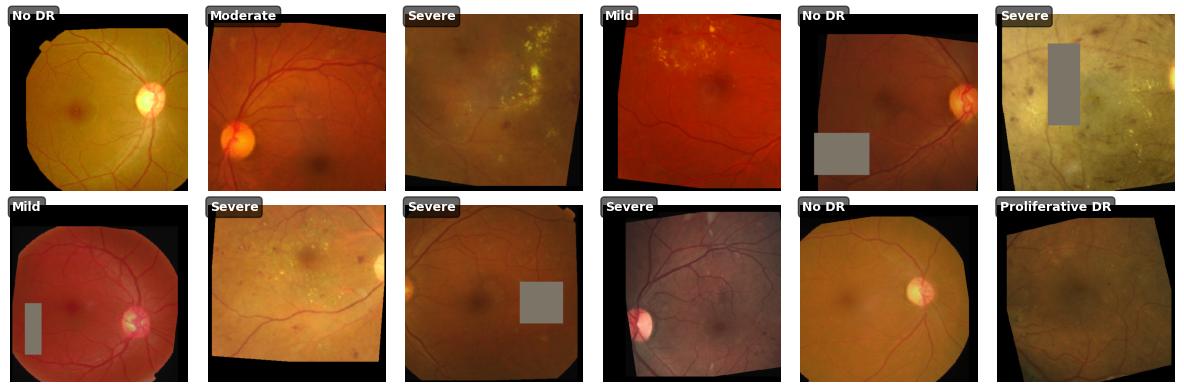

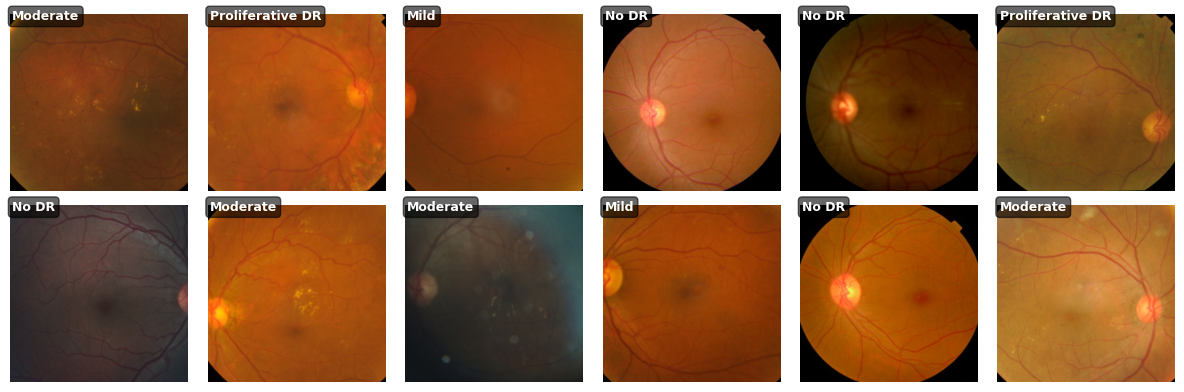

In [30]:
## Sanity Check Visualization
def show_batch(images, labels, n=24, ncols=6):
    """
    Display a batch of images with their labels.
    
    Args:
        images: Tensor of images [B, C, H, W] (can be on any device)
        labels: Tensor of labels [B] (can be on any device)
        n: Number of images to display (default: 24)
        ncols: Number of columns in the grid (default: 6)
    """
    # Ensure images and labels are on CPU for visualization
    if isinstance(images, torch.Tensor):
        images = images.cpu()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu()
    
    n = min(n, len(images))
    nrows = int(np.ceil(n / ncols))
    
    # Use square figsize that scales with grid dimensions to preserve aspect ratio
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    
    # Convert axes to a flat list for easier indexing
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    elif nrows == 1:
        axes_list = list(axes) if hasattr(axes, '__iter__') else [axes]
    elif ncols == 1:
        axes_list = list(axes.flatten()) if hasattr(axes, 'flatten') else [axes]
    else:
        axes_list = list(axes.flatten())
    
    for i in range(n):
        ax = axes_list[i]
        
        # Denormalize and convert to numpy
        img = denorm(images[i])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_aspect("equal")  # Preserve 1:1 aspect ratio so fundus images appear round
        ax.axis('off')
        
        label_text = class_names[int(labels[i])]
        ax.text(
            5, 15, label_text,
            color='white', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )
    
    # Hide unused subplots
    for i in range(n, len(axes_list)):
        axes_list[i].axis('off')
    
    plt.tight_layout()
    plt.show()


print("✓ Data visualization utilities defined!")
print("  - denorm(img_tensor): Denormalize ImageNet-normalized images")
print("  - show_batch(images, labels, n, ncols): Display a batch of images with labels")

#Test visualization (uncomment to run after get_dataloaders is defined)
#train_loader, val_loader, _, _ = get_dataloaders()

# Visualize a batch from training set
print("\nTraining batch sample:")
inputs, labels, img_ids = next(iter(train_loader))
show_batch(inputs, labels, n=12, ncols=6)

# Visualize a batch from validation set  
print("\nValidation batch sample:")
val_inputs, val_labels, val_img_ids = next(iter(val_loader))
show_batch(val_inputs, val_labels, n=12, ncols=6)

In [31]:
## Model Definition: EfficientNet-B4

# Load EfficientNet-B4 with pretrained weights
weights = EfficientNet_B4_Weights.IMAGENET1K_V1
model = efficientnet_b4(weights=weights)

# Freeze all backbone features initially
for p in model.features.parameters():
    p.requires_grad = False

# Replace classifier for 5-class DR
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, NUM_CLASSES)

# Ensure classifier params are trainable
for p in model.classifier.parameters():
    p.requires_grad = True

# Move to device
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model loaded: EfficientNet-B4")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

In [32]:
## Weights & Biases Initialization

# W&B login (will prompt in Colab)
wandb.login()

# Comprehensive W&B configuration
wandb_config = {
    # Model
    "model": "efficientnet_b4",
    "num_classes": NUM_CLASSES,
    "pretrained": "ImageNet1K_V1",
    
    # Data
    "dataset": "APTOS",
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "img_size": CROP_SIZE,
    "batch_size": BATCH_SIZE,
    
    # Training
    "total_epochs": TOTAL_EPOCHS,
    "unfreeze_epoch": UNFREEZE_EPOCH,
    "head_lr": HEAD_LR,
    "backbone_lr": BACKBONE_LR,
    "weight_decay": WEIGHT_DECAY,
    
    # Loss
    "loss": "CrossEntropyLoss",
    "label_smoothing": LABEL_SMOOTHING,
    "class_weights": True,
    "sampling": "WeightedRandomSampler",
    
    # Augmentations
    "augmentations": [
        "SmartFundusCrop",
        f"Resize({IMG_RESIZE})",
        f"RandomResizedCrop({CROP_SIZE}, scale=(0.95, 1.0), ratio=(0.98, 1.02))",
        "RandomHorizontalFlip(p=0.5)",
        "RandomRotation(±10°)",
        "ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.02)",
        "ToTensor",
        "Normalize(ImageNet mean/std)"
    ],
    
    # Model architecture
    "total_params": total_params,
    "trainable_params": trainable_params,
    
    # Reproducibility
    "seed": SEED,
    
    # Explainability
    "gradcam_layer": GRADCAM_LAYER_INDEX,
    "lime_samples": LIME_NUM_SAMPLES,
}

# Initialize W&B run
wandb_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config=wandb_config,
    tags=WANDB_TAGS,
    notes="EfficientNet-B4 for 5-class Diabetic Retinopathy classification on APTOS dataset",
    save_code=True,
)

# Watch model with W&B (gradients and parameters)
wandb.watch(model, log="all", log_freq=100)

print("=" * 60)
print("Weights & Biases Initialized")
print("=" * 60)
print(f"Project: {wandb_run.project}")
print(f"Run: {wandb_run.name}")
print(f"Run ID: {wandb_run.id}")
print(f"URL: {wandb_run.url}")
print("=" * 60)